# Cross-Industry Comparison Analysis
## Using EVENT STUDY PANELS BY SINGLE INDUSTRY

Three cross-industry analyses:
1. **Distribution Difference Tests** — Kruskal-Wallis & ANOVA across industries
2. **Pre[-5,-1] vs Post[0,+5] CAAR decomposition** — Anticipation vs Reaction
3. **Pairwise Significance Matrix** — Which industry pairs differ significantly?



---
## Setup: Load Data & Rebuild AR Matrix

In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import combinations
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')

# ── Paths — UPDATE TO YOUR LOCAL PATHS ────────────────────────────────────
SP500_PATH     = "sp500_2013_2022_daily.csv"
SINGLE_IND_DIR = "EVENT STUDY PANELS BY SINGLE INDUSTRY"

# ── Window parameters ──────────────────────────────────────────────────────
EST_START, EST_END = -250, -10
EVT_START, EVT_END = -5,    5
event_days = list(range(EVT_START, EVT_END + 1))
pre_days   = list(range(-5, 0))
post_days  = list(range(0, 6))

# ── Industry mapping: file prefix → (column name, display label) ──────────
INDUSTRY_MAP = {
    'Airl':  ('Airlines_&_Travel_daily_return',                           'Airlines & Travel'),
    'Auto':  ('Automobiles_&_Auto_Components_daily_return',               'Automobiles'),
    'Chem':  ('Chemicals_(Materials_sector)_daily_return',                'Chemicals'),
    'Cons':  ('Construction_&_Infrastructure_daily_return',               'Construction'),
    'Defe':  ('Defense_&_Aerospace_daily_return',                         'Defense & Aerospace'),
    'Fina':  ('Financials_(Banks)_daily_return',                          'Financials (Banks)'),
    'News':  ('News_&_Publishing_daily_return',                           'News & Publishing'),
    'Oil':   ('Oil_&_Natural_Gas_daily_return',                           'Oil & Gas'),
    'Semi':  ('Semiconductors_(Information_Technology_sector)_daily_return','Semiconductors'),
    'Tech':  ('Technology_&_Internet_daily_return',                       'Technology & Internet'),
}
INDUSTRIES      = list(INDUSTRY_MAP.keys())
INDUSTRY_COLS   = {k: v[0] for k, v in INDUSTRY_MAP.items()}
INDUSTRY_LABELS = {k: v[1] for k, v in INDUSTRY_MAP.items()}
SHORT_LABELS    = [INDUSTRY_LABELS[p] for p in INDUSTRIES]
colors          = plt.cm.tab10(np.linspace(0, 1, 10))
COLOR_MAP       = {p: colors[i] for i, p in enumerate(INDUSTRIES)}

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return ''

print("✅ Configuration loaded.")

✅ Configuration loaded.


In [2]:
# ── Load S&P 500 ───────────────────────────────────────────────────────────
sp500 = pd.read_csv(SP500_PATH, skiprows=[1], parse_dates=['Date'])
sp500 = sp500[['Date','Market_Return']].dropna()
sp500['Market_Return'] = pd.to_numeric(sp500['Market_Return'], errors='coerce')
sp500 = sp500.dropna().set_index('Date').sort_index()

# ── Load all single-industry panels ───────────────────────────────────────
panels = {}
for prefix in INDUSTRIES:
    pattern = os.path.join(SINGLE_IND_DIR, f"{prefix}_panel_tweet_id_*.csv")
    files   = sorted(glob.glob(pattern))
    tweet_panels = []
    for f in files:
        tid = os.path.basename(f).replace(f"{prefix}_panel_tweet_id_","").replace(".csv","")
        df  = pd.read_csv(f, parse_dates=['Day'])
        df['t'] = pd.to_numeric(df['t'], errors='coerce')
        df  = df.dropna(subset=['t']).set_index('t').sort_index()
        df2 = df.reset_index()
        df2['Day'] = pd.to_datetime(df2['Day'])
        df2 = df2.merge(
            sp500.reset_index().rename(columns={'Date':'Day'}),
            on='Day', how='left'
        ).set_index('t').sort_index()
        tweet_panels.append((tid, df2))
    panels[prefix] = tweet_panels

print(f"✅ Panels loaded: {sum(len(v) for v in panels.values())} total files")

✅ Panels loaded: 233 total files


In [3]:
# ── Estimate CAPM and compute AR matrix ───────────────────────────────────
param_store = {}
ar_matrix   = {p: {t: [] for t in event_days} for p in INDUSTRIES}

for prefix in INDUSTRIES:
    ret_col = INDUSTRY_COLS[prefix]
    param_store[prefix] = {}
    
    for tid, df in panels[prefix]:
        # Find return column
        rc = ret_col if ret_col in df.columns else next(
            (c for c in df.columns if 'return' in c.lower()), None)
        if rc is None: continue
        
        # OLS estimation
        est = df[(df.index >= EST_START) & (df.index <= EST_END)][[' Market_Return', rc] \
              if ' Market_Return' in df.columns else ['Market_Return', rc]].dropna()
        # handle column name safely
        mkt_col = 'Market_Return' if 'Market_Return' in df.columns else None
        if mkt_col is None: continue
        est = df[(df.index >= EST_START) & (df.index <= EST_END)][[mkt_col, rc]].dropna()
        
        if len(est) < 30:
            param_store[prefix][tid] = (np.nan, np.nan)
            continue
        X = sm.add_constant(est[mkt_col].values)
        try:
            m = sm.OLS(est[rc].values, X).fit()
            param_store[prefix][tid] = (m.params[0], m.params[1])
        except:
            param_store[prefix][tid] = (np.nan, np.nan)
            continue
        
        # Compute AR in event window
        alpha, beta = param_store[prefix][tid]
        if np.isnan(alpha): continue
        evt = df[(df.index >= EVT_START) & (df.index <= EVT_END)]
        for t in event_days:
            if t not in evt.index: continue
            row = evt.loc[t]
            r_a = row[rc]
            r_m = row[mkt_col]
            if pd.isna(r_a) or pd.isna(r_m): continue
            ar_matrix[prefix][t].append(r_a - (alpha + beta * r_m))

# ── Build results dict ─────────────────────────────────────────────────────
results = {}
for prefix in INDUSTRIES:
    rows = []
    for t in event_days:
        ars = ar_matrix[prefix][t]; n = len(ars)
        if n == 0:
            rows.append({'t':t,'AAR':np.nan,'SE':np.nan,'N':0,'t_stat':np.nan,'p_value':np.nan})
            continue
        aar = np.mean(ars); se = np.std(ars,ddof=1)/np.sqrt(n)
        t_s = aar/se if se>0 else np.nan
        p_v = 2*stats.t.sf(abs(t_s),df=n-1) if not np.isnan(t_s) else np.nan
        rows.append({'t':t,'AAR':aar,'SE':se,'N':n,'t_stat':t_s,'p_value':p_v})
    df_r = pd.DataFrame(rows).set_index('t')
    df_r['CAAR']    = df_r['AAR'].cumsum()
    df_r['CAAR_SE'] = np.sqrt(df_r['SE'].pow(2).cumsum().replace(0,np.nan))
    df_r['CAAR_p']  = df_r.apply(
        lambda r: 2*stats.t.sf(abs(r['CAAR']/r['CAAR_SE']),df=r['N']-1)
        if not np.isnan(r['CAAR_SE']) and r['CAAR_SE']>0 else np.nan, axis=1)
    results[prefix] = df_r

print("✅ AR matrix and results ready.")
print("Event counts at t=0:")
for p in INDUSTRIES:
    print(f"  {INDUSTRY_LABELS[p]:<35} N={len(ar_matrix[p][0])}")

✅ AR matrix and results ready.
Event counts at t=0:
  Airlines & Travel                   N=6
  Automobiles                         N=14
  Chemicals                           N=1
  Construction                        N=1
  Defense & Aerospace                 N=10
  Financials (Banks)                  N=3
  News & Publishing                   N=88
  Oil & Gas                           N=1
  Semiconductors                      N=16
  Technology & Internet               N=85


---
## Section 1: Distribution Difference Tests

**Goal:** Test whether AR distributions differ significantly across industries at each event day.

- **Kruskal-Wallis H-test** (non-parametric): $H_0$: all industries share the same AR distribution
- **ANOVA F-test** (parametric): $H_0$: all industry mean ARs are equal

In [4]:
kw_rows, anova_rows = [], []
for t in event_days:
    groups = [ar_matrix[p][t] for p in INDUSTRIES if len(ar_matrix[p][t]) >= 5]
    if len(groups) < 2:
        kw_rows.append({'t':t,'H_stat':np.nan,'p_kw':np.nan})
        anova_rows.append({'t':t,'F_stat':np.nan,'p_anova':np.nan})
        continue
    H, p_kw    = stats.kruskal(*groups)
    F, p_anova = stats.f_oneway(*groups)
    kw_rows.append({'t':t,'H_stat':H,'p_kw':p_kw})
    anova_rows.append({'t':t,'F_stat':F,'p_anova':p_anova})

kw_df    = pd.DataFrame(kw_rows).set_index('t')
anova_df = pd.DataFrame(anova_rows).set_index('t')

print("=" * 65)
print("INTER-INDUSTRY DISTRIBUTION TESTS BY EVENT DAY")
print("=" * 65)
print(f"{'t':>4}  {'K-W H':>8}  {'p(KW)':>8}  {'Sig':>4}  {'F':>8}  {'p(ANOVA)':>9}  {'Sig':>4}")
print("-" * 65)
for t in event_days:
    H  = kw_df.loc[t,'H_stat'];   pk = kw_df.loc[t,'p_kw']
    F  = anova_df.loc[t,'F_stat']; pa = anova_df.loc[t,'p_anova']
    mk = " ◄" if t == 0 else ""
    print(f"{t:>4}  {H:>8.3f}  {pk:>8.4f}  {sig_stars(pk):>4}  "
          f"{F:>8.3f}  {pa:>9.4f}  {sig_stars(pa):>4}{mk}")
print("-" * 65)
print("* p<0.10  ** p<0.05  *** p<0.01")

INTER-INDUSTRY DISTRIBUTION TESTS BY EVENT DAY
   t     K-W H     p(KW)   Sig         F   p(ANOVA)   Sig
-----------------------------------------------------------------
  -5     3.421    0.7545           0.736     0.6215      
  -4     6.397    0.3802           1.075     0.3782      
  -3     7.960    0.2410           1.700     0.1222      
  -2     5.277    0.5088           0.855     0.5291      
  -1     5.436    0.4892           1.187     0.3145      
   0     4.069    0.5395           0.378     0.8635       ◄
   1     7.616    0.2676           0.707     0.6440      
   2     9.456    0.1495           1.004     0.4237      
   3     1.475    0.9611           0.582     0.7447      
   4    12.539    0.0510     *     1.811     0.0984     *
   5     8.385    0.1363           0.875     0.4991      
-----------------------------------------------------------------
* p<0.10  ** p<0.05  *** p<0.01


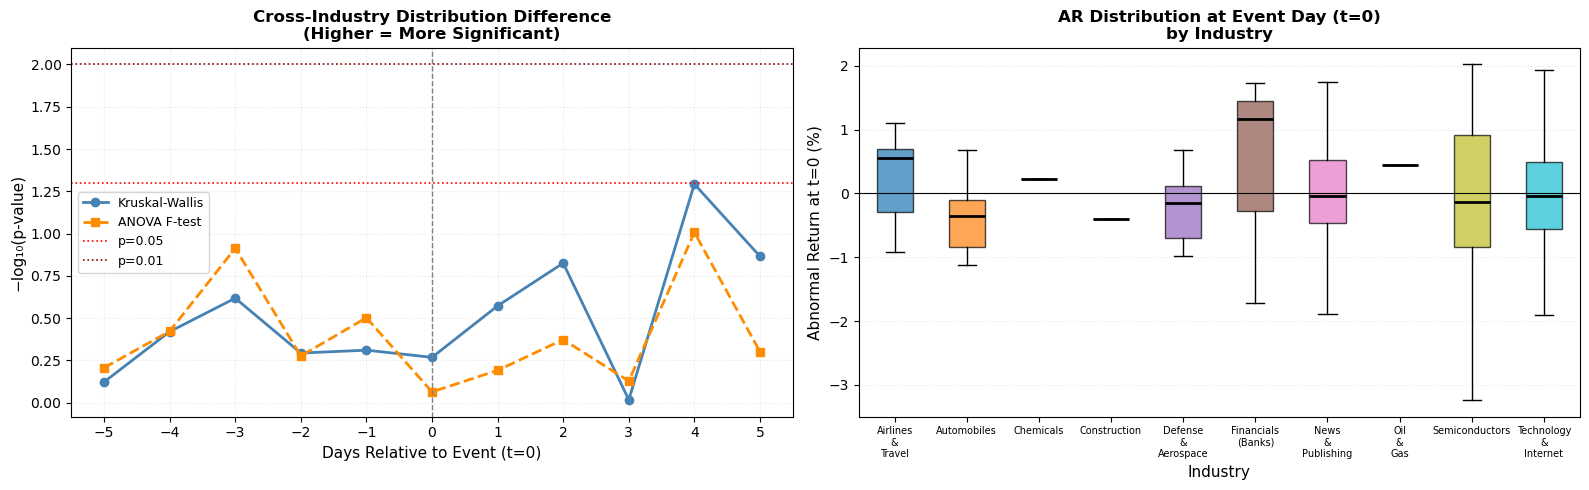

✅ Saved: cross_industry_distribution_test.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: -log10(p) timeline
ax = axes[0]
log_kw    = -np.log10(np.clip(kw_df['p_kw'].values, 1e-10, 1))
log_anova = -np.log10(np.clip(anova_df['p_anova'].values, 1e-10, 1))
ax.plot(event_days, log_kw,    'o-',  color='steelblue',  linewidth=2, label='Kruskal-Wallis')
ax.plot(event_days, log_anova, 's--', color='darkorange', linewidth=2, label='ANOVA F-test')
ax.axhline(-np.log10(0.05), color='red',     linestyle=':', linewidth=1.2, label='p=0.05')
ax.axhline(-np.log10(0.01), color='darkred', linestyle=':', linewidth=1.2, label='p=0.01')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.fill_between(event_days, -np.log10(0.05), log_kw,
                where=log_kw > -np.log10(0.05), alpha=0.15, color='steelblue')
ax.set_xlabel('Days Relative to Event (t=0)', fontsize=11)
ax.set_ylabel('−log₁₀(p-value)', fontsize=11)
ax.set_title('Cross-Industry Distribution Difference\n(Higher = More Significant)',
             fontsize=12, fontweight='bold')
ax.set_xticks(event_days); ax.legend(fontsize=9); ax.grid(alpha=0.3, linestyle=':')

# Right: AR boxplot at t=0
ax2 = axes[1]
ar_at_0 = [np.array(ar_matrix[p][0])*100 for p in INDUSTRIES]
bp = ax2.boxplot(ar_at_0,
                 labels=[INDUSTRY_LABELS[p].replace(' ','\n') for p in INDUSTRIES],
                 patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Industry', fontsize=11)
ax2.set_ylabel('Abnormal Return at t=0 (%)', fontsize=11)
ax2.set_title('AR Distribution at Event Day (t=0)\nby Industry',
              fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', labelsize=7)
ax2.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('cross_industry_distribution_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cross_industry_distribution_test.png")

---
## Section 2: Pre vs. Post CAAR Decomposition

$$CAAR_{pre} = \sum_{t=-5}^{-1} AAR_t \qquad CAAR_{post} = \sum_{t=0}^{+5} AAR_t$$

In [6]:
def caar_segment(ar_dict, t_list):
    """Compute CAAR and significance by summing per-event CARs across t_list."""
    event_cars = {}
    for t in t_list:
        for i, ar in enumerate(ar_dict[t]):
            event_cars[i] = event_cars.get(i, 0) + ar
    cars = list(event_cars.values())
    if len(cars) < 2:
        return np.nan, np.nan, np.nan, len(cars)
    caar = np.mean(cars)
    se   = np.std(cars, ddof=1) / np.sqrt(len(cars))
    t_s  = caar / se if se > 0 else np.nan
    p_v  = 2 * stats.t.sf(abs(t_s), df=len(cars)-1) if not np.isnan(t_s) else np.nan
    return caar * 100, se * 100, p_v, len(cars)

seg_rows = []
for prefix in INDUSTRIES:
    pre_c, pre_se, pre_p, _ = caar_segment(ar_matrix[prefix], pre_days)
    pos_c, pos_se, pos_p, _ = caar_segment(ar_matrix[prefix], post_days)
    ful_c, ful_se, ful_p, _ = caar_segment(ar_matrix[prefix], event_days)
    seg_rows.append({
        'prefix': prefix,
        'Industry': INDUSTRY_LABELS[prefix],
        'Pre CAAR[-5,-1]':  f"{pre_c:.4f}%",  'Pre Sig':  sig_stars(pre_p),
        'Pre p':  f"{pre_p:.4f}" if not pd.isna(pre_p) else '-',
        'Post CAAR[0,+5]':  f"{pos_c:.4f}%",  'Post Sig': sig_stars(pos_p),
        'Post p': f"{pos_p:.4f}" if not pd.isna(pos_p) else '-',
        'Full CAAR[-5,+5]': f"{ful_c:.4f}%",  'Full Sig': sig_stars(ful_p),
        '_pre_val': pre_c, '_pre_se': pre_se,
        '_pos_val': pos_c, '_pos_se': pos_se,
        '_ful_val': ful_c, '_ful_se': ful_se,
    })

seg_df = pd.DataFrame(seg_rows)
disp   = ['Industry','Pre CAAR[-5,-1]','Pre Sig','Pre p',
          'Post CAAR[0,+5]','Post Sig','Post p','Full CAAR[-5,+5]','Full Sig']
print("=" * 105)
print("PRE vs POST CAAR DECOMPOSITION")
print("=" * 105)
print(seg_df[disp].to_string(index=False))
print("\n* p<0.10  ** p<0.05  *** p<0.01")

PRE vs POST CAAR DECOMPOSITION
             Industry Pre CAAR[-5,-1] Pre Sig  Pre p Post CAAR[0,+5] Post Sig Post p Full CAAR[-5,+5] Full Sig
    Airlines & Travel        -0.3700%         0.5928         1.2565%          0.1692          0.8864%         
          Automobiles         0.1401%         0.8508        -0.2834%          0.6699         -0.1432%         
            Chemicals            nan%              -            nan%               -             nan%         
         Construction            nan%              -            nan%               -             nan%         
  Defense & Aerospace        -0.0943%         0.7866        -0.7526%          0.3454         -0.8470%         
   Financials (Banks)        -3.1893%      ** 0.0242         0.1087%          0.9279         -3.0806%         
    News & Publishing        -0.7482%     *** 0.0060        -0.3788%          0.3133         -1.1270%       **
            Oil & Gas            nan%              -            nan%             

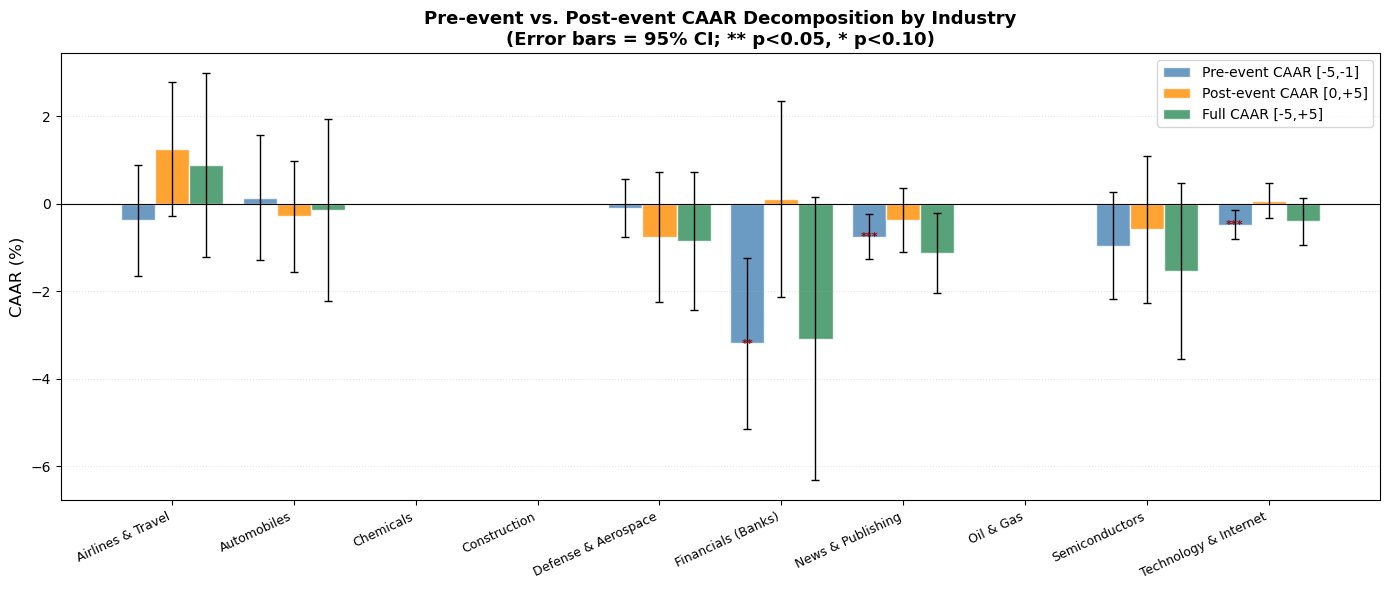

✅ Saved: pre_post_CAAR_comparison.png


In [7]:
# ── Grouped bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(INDUSTRIES)); w = 0.28

pre_v = seg_df['_pre_val'].values; pre_e = 1.96 * seg_df['_pre_se'].values
pos_v = seg_df['_pos_val'].values; pos_e = 1.96 * seg_df['_pos_se'].values
ful_v = seg_df['_ful_val'].values; ful_e = 1.96 * seg_df['_ful_se'].values

ax.bar(x-w, pre_v, w, label='Pre-event CAAR [-5,-1]', color='steelblue',  alpha=0.8, edgecolor='white')
ax.bar(x,   pos_v, w, label='Post-event CAAR [0,+5]', color='darkorange', alpha=0.8, edgecolor='white')
ax.bar(x+w, ful_v, w, label='Full CAAR [-5,+5]',      color='seagreen',   alpha=0.8, edgecolor='white')
ax.errorbar(x-w, pre_v, yerr=pre_e, fmt='none', color='black', capsize=3, linewidth=1)
ax.errorbar(x,   pos_v, yerr=pos_e, fmt='none', color='black', capsize=3, linewidth=1)
ax.errorbar(x+w, ful_v, yerr=ful_e, fmt='none', color='black', capsize=3, linewidth=1)

# Significance stars above bars
for i, row in seg_df.iterrows():
    for val, p_str, offset in [
        (row['_pre_val'], row['Pre p'],  -w),
        (row['_pos_val'], row['Post p'],  0),
    ]:
        try:
            stars = sig_stars(float(p_str)) if p_str != '-' else ''
            if stars:
                ax.text(i+offset, val+(0.04 if val>=0 else -0.08),
                        stars, ha='center', fontsize=8, color='darkred', fontweight='bold')
        except: pass

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(SHORT_LABELS, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('CAAR (%)', fontsize=12)
ax.set_title('Pre-event vs. Post-event CAAR Decomposition by Industry\n'
             '(Error bars = 95% CI; ** p<0.05, * p<0.10)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('pre_post_CAAR_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pre_post_CAAR_comparison.png")

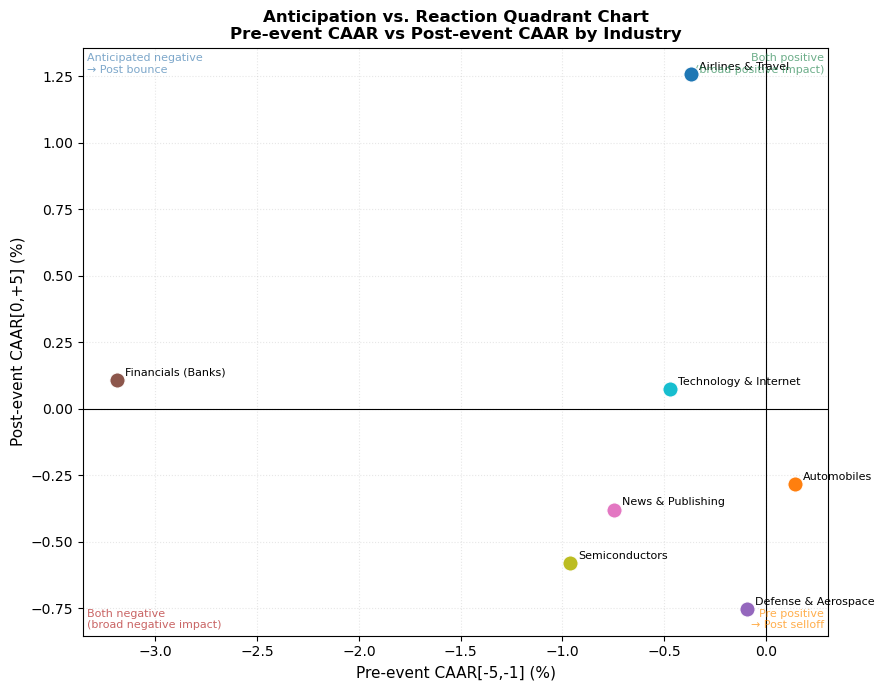

✅ Saved: pre_post_scatter_quadrant.png


In [8]:
# ── Anticipation vs Reaction quadrant scatter ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for i, prefix in enumerate(INDUSTRIES):
    row = seg_df[seg_df['prefix'] == prefix].iloc[0]
    ax.scatter(row['_pre_val'], row['_pos_val'],
               color=COLOR_MAP[prefix], s=120, zorder=5, edgecolor='white', linewidth=0.8)
    ax.annotate(INDUSTRY_LABELS[prefix], (row['_pre_val'], row['_pos_val']),
                textcoords='offset points', xytext=(6,3), fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
xl = ax.get_xlim(); yl = ax.get_ylim()
ax.text(xl[1]-0.02, yl[1]-0.02, 'Both positive\n(broad positive impact)',
        ha='right', va='top', fontsize=8, color='seagreen', alpha=0.7)
ax.text(xl[0]+0.02, yl[1]-0.02, 'Anticipated negative\n→ Post bounce',
        ha='left',  va='top', fontsize=8, color='steelblue', alpha=0.7)
ax.text(xl[1]-0.02, yl[0]+0.02, 'Pre positive\n→ Post selloff',
        ha='right', va='bottom', fontsize=8, color='darkorange', alpha=0.7)
ax.text(xl[0]+0.02, yl[0]+0.02, 'Both negative\n(broad negative impact)',
        ha='left',  va='bottom', fontsize=8, color='firebrick', alpha=0.7)

ax.set_xlabel('Pre-event CAAR[-5,-1] (%)', fontsize=11)
ax.set_ylabel('Post-event CAAR[0,+5] (%)', fontsize=11)
ax.set_title('Anticipation vs. Reaction Quadrant Chart\n'
             'Pre-event CAAR vs Post-event CAAR by Industry',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('pre_post_scatter_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pre_post_scatter_quadrant.png")

---
## Section 3: Pairwise CAAR Significance Matrix

**Goal:** Two-sample Welch t-test on per-event CAR distributions for every industry pair.
Benjamini-Hochberg correction for multiple comparisons.

$$H_0: \mu_{CAR_A} = \mu_{CAR_B}$$

In [9]:
# Per-event CAR for each industry (sum AR over full event window)
def get_event_cars(ar_dict, t_list):
    max_n = max((len(ar_dict[t]) for t in t_list if ar_dict[t]), default=0)
    if max_n == 0: return np.array([])
    cars = np.full(max_n, np.nan)
    for i in range(max_n):
        s, c = 0, 0
        for t in t_list:
            if i < len(ar_dict[t]):
                s += ar_dict[t][i]; c += 1
        if c > 0: cars[i] = s
    return cars[~np.isnan(cars)]

industry_cars = {p: get_event_cars(ar_matrix[p], event_days) for p in INDUSTRIES}

# Pairwise Welch t-tests
pair_results = []
for p_a, p_b in combinations(INDUSTRIES, 2):
    ca, cb = industry_cars[p_a], industry_cars[p_b]
    if len(ca) < 5 or len(cb) < 5:
        pair_results.append({'a':p_a,'b':p_b,'t_stat':np.nan,'p_raw':np.nan})
        continue
    t_s, p_v = stats.ttest_ind(ca, cb, equal_var=False)
    pair_results.append({'a':p_a,'b':p_b,'t_stat':t_s,'p_raw':p_v})

pair_df   = pd.DataFrame(pair_results)
valid_idx = pair_df['p_raw'].notna()
if valid_idx.sum() > 0:
    _, p_bh, _, _ = multipletests(pair_df.loc[valid_idx,'p_raw'].values, method='fdr_bh')
    pair_df.loc[valid_idx, 'p_bh'] = p_bh

print(f"✅ Pairwise tests: {len(pair_df)} pairs")
sig_pairs = pair_df[pair_df.get('p_bh', pair_df['p_raw']) < 0.05]
print(f"   Significant after BH correction (p<0.05): {len(sig_pairs)}")
print("\nTop significant pairs:")
top = pair_df.dropna(subset=['p_raw']).sort_values('p_raw').head(10).copy()
top['A'] = top['a'].map(INDUSTRY_LABELS)
top['B'] = top['b'].map(INDUSTRY_LABELS)
top['CAAR_A%'] = top['a'].map(lambda x: f"{np.mean(industry_cars[x])*100:.4f}%")
top['CAAR_B%'] = top['b'].map(lambda x: f"{np.mean(industry_cars[x])*100:.4f}%")
print(top[['A','CAAR_A%','B','CAAR_B%','t_stat','p_raw','p_bh']].round(4).to_string(index=False))

✅ Pairwise tests: 45 pairs
   Significant after BH correction (p<0.05): 0

Top significant pairs:
                  A  CAAR_A%                     B  CAAR_B%  t_stat  p_raw   p_bh
  Airlines & Travel  0.8864%    Financials (Banks) -3.0806%  2.0161 0.0762 0.5723
  Airlines & Travel  0.8864%        Semiconductors -1.5419%  1.6362 0.1234 0.5723
  Airlines & Travel  0.8864%     News & Publishing -1.1270%  1.7225 0.1280 0.5723
 Financials (Banks) -3.0806% Technology & Internet -0.4007% -1.6006 0.1673 0.5723
        Automobiles -0.1432%    Financials (Banks) -3.0806%  1.4971 0.1673 0.5723
  News & Publishing -1.1270% Technology & Internet -0.4007% -1.3312 0.1852 0.5723
  Airlines & Travel  0.8864%   Defense & Aerospace -0.8470%  1.2944 0.2235 0.5723
Defense & Aerospace -0.8470%    Financials (Banks) -3.0806%  1.2156 0.2613 0.5723
  Airlines & Travel  0.8864% Technology & Internet -0.4007%  1.1652 0.2905 0.5723
     Semiconductors -1.5419% Technology & Internet -0.4007% -1.0716 0.2987 0.5723


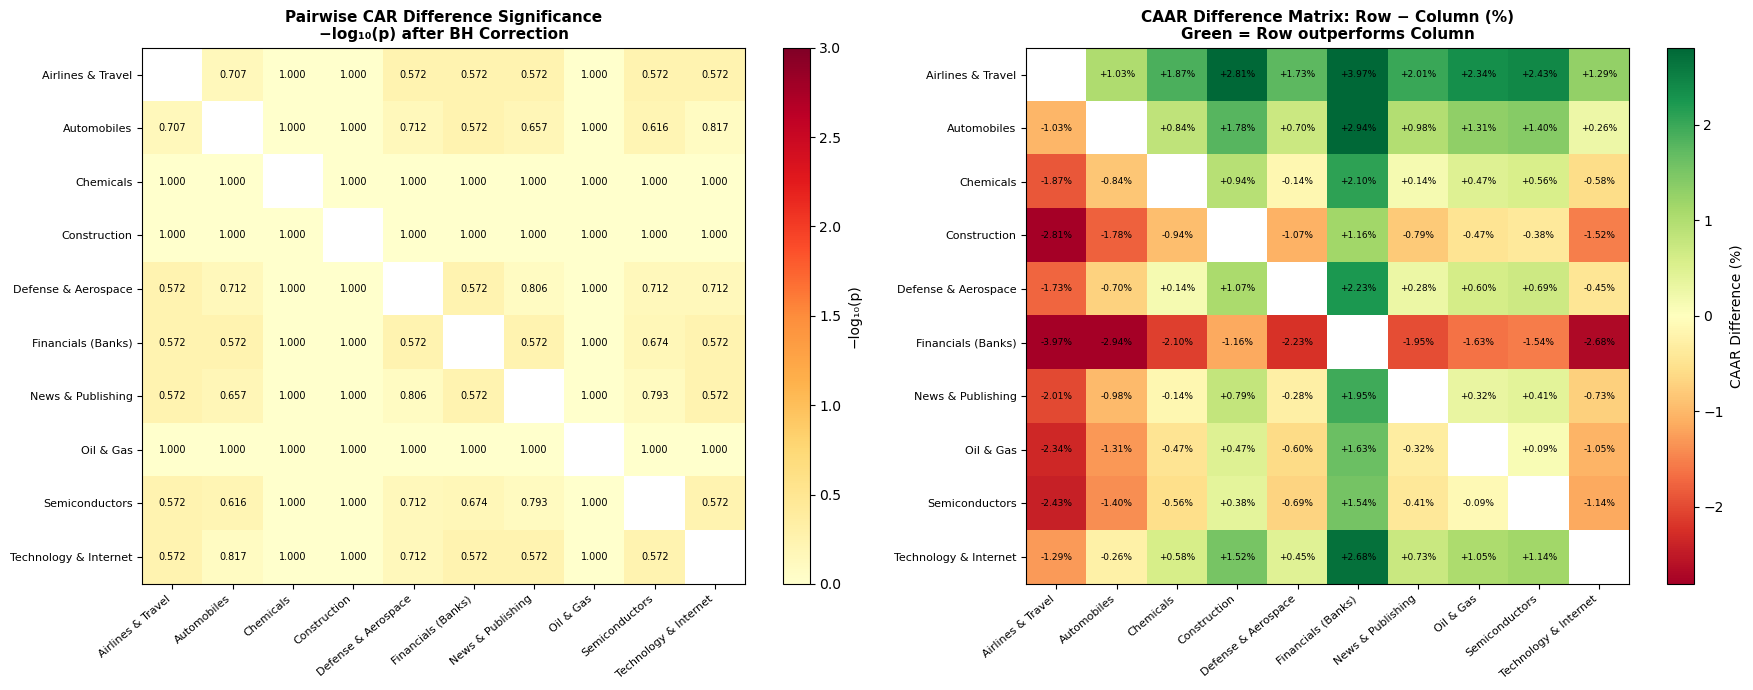

✅ Saved: pairwise_significance_matrix.png


In [10]:
# ── Build p-value and difference matrices ─────────────────────────────────
n = len(INDUSTRIES)
ind_idx    = {p: i for i, p in enumerate(INDUSTRIES)}
p_matrix   = np.ones((n, n))
diff_matrix= np.zeros((n, n))
mean_cars  = {p: np.mean(industry_cars[p])*100 if len(industry_cars[p])>0 else np.nan
              for p in INDUSTRIES}

for _, row in pair_df.iterrows():
    i, j = ind_idx[row['a']], ind_idx[row['b']]
    p_val = row.get('p_bh', row['p_raw'])
    p_val = p_val if not pd.isna(p_val) else 1.0
    p_matrix[i,j] = p_matrix[j,i] = p_val

for i, p_i in enumerate(INDUSTRIES):
    for j, p_j in enumerate(INDUSTRIES):
        if i != j:
            diff_matrix[i,j] = mean_cars[p_i] - mean_cars[p_j]

np.fill_diagonal(p_matrix,    np.nan)
np.fill_diagonal(diff_matrix, np.nan)

# ── Plot two heatmaps side by side ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: significance
ax1 = axes[0]
log_p = -np.log10(np.clip(p_matrix, 1e-10, 1))
np.fill_diagonal(log_p, np.nan)
im1 = ax1.imshow(log_p, cmap='YlOrRd', aspect='auto', vmin=0, vmax=3)
for i in range(n):
    for j in range(n):
        if i == j: continue
        p_v = p_matrix[i,j]; stars = sig_stars(p_v)
        txt = f"{p_v:.3f}{stars}" if not np.isnan(p_v) else ""
        ax1.text(j, i, txt, ha='center', va='center', fontsize=7,
                 color='black' if log_p[i,j] < 2 else 'white')
ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
ax1.set_xticklabels(SHORT_LABELS, rotation=40, ha='right', fontsize=8)
ax1.set_yticklabels(SHORT_LABELS, fontsize=8)
ax1.set_title('Pairwise CAR Difference Significance\n−log₁₀(p) after BH Correction',
              fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='−log₁₀(p)')

# Right: difference direction
ax2 = axes[1]
vmax_d = np.nanpercentile(np.abs(diff_matrix), 95)
im2 = ax2.imshow(diff_matrix, cmap='RdYlGn', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
for i in range(n):
    for j in range(n):
        if i == j: continue
        val = diff_matrix[i,j]; p_v = p_matrix[i,j]
        ax2.text(j, i, f"{val:+.2f}%{sig_stars(p_v)}",
                 ha='center', va='center', fontsize=6.5, color='black')
ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
ax2.set_xticklabels(SHORT_LABELS, rotation=40, ha='right', fontsize=8)
ax2.set_yticklabels(SHORT_LABELS, fontsize=8)
ax2.set_title('CAAR Difference Matrix: Row − Column (%)\nGreen = Row outperforms Column',
              fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='CAAR Difference (%)')

plt.tight_layout()
plt.savefig('pairwise_significance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pairwise_significance_matrix.png")

---
## Section 4: Comprehensive Summary Dashboard

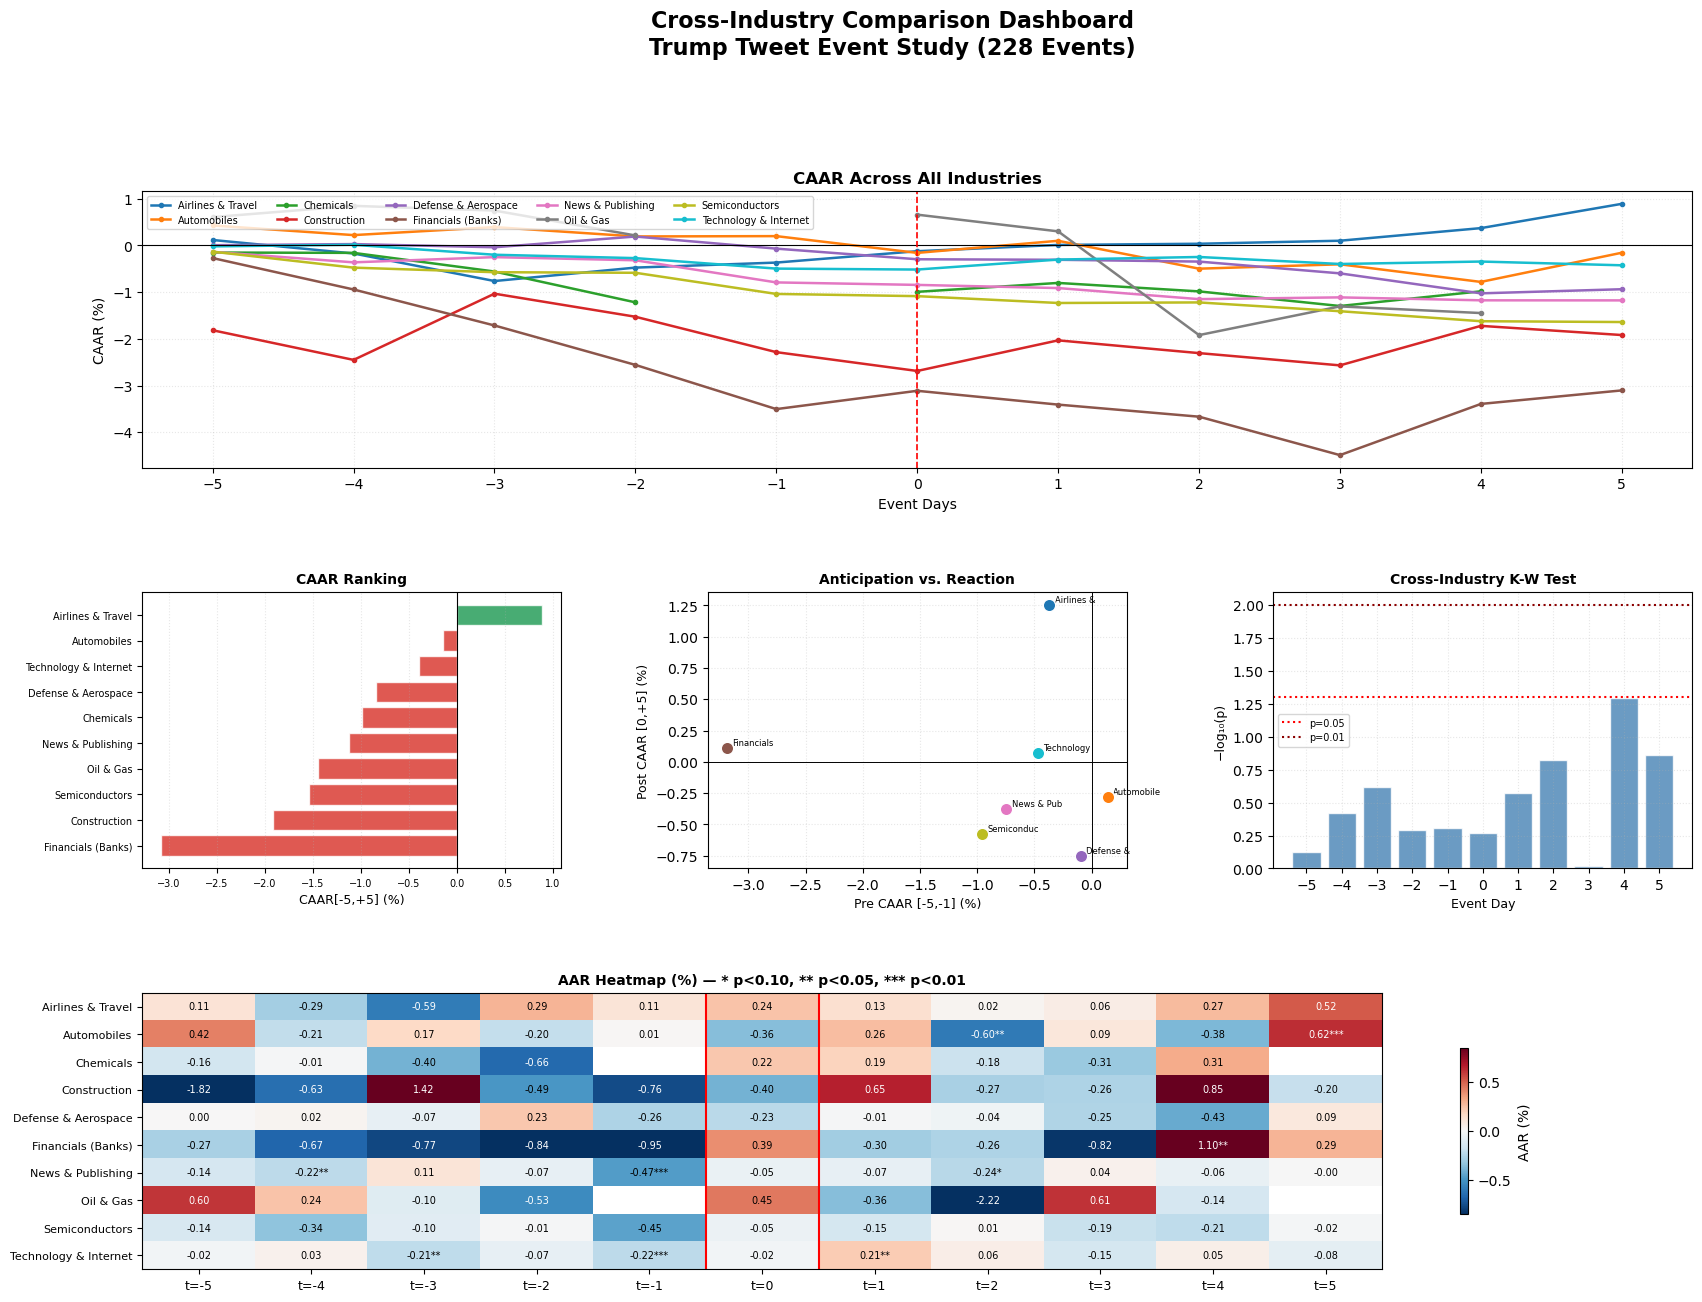

✅ Saved: cross_industry_dashboard.png


In [11]:
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)
ax_caar    = fig.add_subplot(gs[0, :])
ax_ranking = fig.add_subplot(gs[1, 0])
ax_prepost = fig.add_subplot(gs[1, 1])
ax_kw      = fig.add_subplot(gs[1, 2])
ax_heat    = fig.add_subplot(gs[2, :])

# 1. CAAR overlay
for prefix in INDUSTRIES:
    df_r  = results[prefix]
    caar  = df_r['CAAR'].values * 100
    ax_caar.plot(df_r.index.tolist(), caar,
                 color=COLOR_MAP[prefix], linewidth=1.8, marker='o', markersize=3,
                 label=INDUSTRY_LABELS[prefix])
ax_caar.axhline(0, color='black', linewidth=0.8)
ax_caar.axvline(0, color='red', linewidth=1.2, linestyle='--')
ax_caar.set_xlabel('Event Days'); ax_caar.set_ylabel('CAAR (%)')
ax_caar.set_title('CAAR Across All Industries', fontweight='bold')
ax_caar.legend(ncol=5, fontsize=7, loc='upper left')
ax_caar.set_xticks(event_days); ax_caar.grid(alpha=0.3, linestyle=':')

# 2. Ranking bar
caars_v = [mean_cars[p] for p in INDUSTRIES]
sort_i  = np.argsort(caars_v)
bc = ['#d73027' if caars_v[i] < 0 else '#1a9850' for i in sort_i]
ax_ranking.barh([SHORT_LABELS[i] for i in sort_i],
                [caars_v[i]      for i in sort_i],
                color=bc, alpha=0.8, edgecolor='white')
ax_ranking.axvline(0, color='black', linewidth=0.8)
ax_ranking.set_xlabel('CAAR[-5,+5] (%)', fontsize=9)
ax_ranking.set_title('CAAR Ranking', fontweight='bold', fontsize=10)
ax_ranking.tick_params(labelsize=7)
ax_ranking.grid(axis='x', alpha=0.3, linestyle=':')

# 3. Pre vs Post scatter
for prefix in INDUSTRIES:
    row = seg_df[seg_df['prefix']==prefix].iloc[0]
    ax_prepost.scatter(row['_pre_val'], row['_pos_val'],
                       color=COLOR_MAP[prefix], s=80, zorder=5, edgecolor='white')
    ax_prepost.annotate(INDUSTRY_LABELS[prefix][:10], (row['_pre_val'], row['_pos_val']),
                        textcoords='offset points', xytext=(4,2), fontsize=6)
ax_prepost.axhline(0, color='black', linewidth=0.7)
ax_prepost.axvline(0, color='black', linewidth=0.7)
ax_prepost.set_xlabel('Pre CAAR [-5,-1] (%)', fontsize=9)
ax_prepost.set_ylabel('Post CAAR [0,+5] (%)', fontsize=9)
ax_prepost.set_title('Anticipation vs. Reaction', fontweight='bold', fontsize=10)
ax_prepost.grid(alpha=0.3, linestyle=':')

# 4. K-W test
lp = -np.log10(np.clip(kw_df['p_kw'].values, 1e-10, 1))
bc2 = ['#d73027' if v > -np.log10(0.05) else 'steelblue' for v in lp]
ax_kw.bar(event_days, lp, color=bc2, alpha=0.8, edgecolor='white')
ax_kw.axhline(-np.log10(0.05), color='red',     linestyle=':', label='p=0.05')
ax_kw.axhline(-np.log10(0.01), color='darkred', linestyle=':', label='p=0.01')
ax_kw.set_xlabel('Event Day', fontsize=9); ax_kw.set_ylabel('−log₁₀(p)', fontsize=9)
ax_kw.set_title('Cross-Industry K-W Test', fontweight='bold', fontsize=10)
ax_kw.set_xticks(event_days); ax_kw.legend(fontsize=7)
ax_kw.grid(alpha=0.3, linestyle=':')

# 5. AAR heatmap
aar_mat  = np.full((n, len(event_days)), np.nan)
pval_mat = np.full((n, len(event_days)), np.nan)
for i, prefix in enumerate(INDUSTRIES):
    for j, t in enumerate(event_days):
        if t in results[prefix].index:
            aar_mat[i,j]  = results[prefix].loc[t,'AAR']*100
            pval_mat[i,j] = results[prefix].loc[t,'p_value']
vmax_h = np.nanpercentile(np.abs(aar_mat), 95)
im = ax_heat.imshow(aar_mat, cmap='RdBu_r', aspect='auto', vmin=-vmax_h, vmax=vmax_h)
for i in range(n):
    for j in range(len(event_days)):
        val = aar_mat[i,j]
        if not np.isnan(val):
            ax_heat.text(j, i, f"{val:.2f}{sig_stars(pval_mat[i,j])}",
                         ha='center', va='center', fontsize=7,
                         color='black' if abs(val)<vmax_h*0.6 else 'white')
ax_heat.set_xticks(range(len(event_days)))
ax_heat.set_xticklabels([f't={t}' for t in event_days], fontsize=9)
ax_heat.set_yticks(range(n))
ax_heat.set_yticklabels(SHORT_LABELS, fontsize=8)
ax_heat.set_title('AAR Heatmap (%) — * p<0.10, ** p<0.05, *** p<0.01',
                  fontweight='bold', fontsize=10)
ev_col = event_days.index(0)
ax_heat.axvline(ev_col-0.5, color='red', linewidth=1.5)
ax_heat.axvline(ev_col+0.5, color='red', linewidth=1.5)
plt.colorbar(im, ax=ax_heat, label='AAR (%)', shrink=0.6)

fig.suptitle('Cross-Industry Comparison Dashboard\nTrump Tweet Event Study (228 Events)',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('cross_industry_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()
print("✅ Saved: cross_industry_dashboard.png")